## Test Inference on 1 image 

In [1]:
import os 
os.getcwd()


'/users/eleves-a/2025/youssef.sidhom/Object_detection_in_documents'

In [2]:
from utils.Qwen_25_LLM import Qwen_llm

BASE_MODEL_PATH = "Qwen/Qwen2.5-VL-3B-Instruct"

# The directory where SFTTrainer saved your fine-tuned adapter
ADAPTER_PATH = "output/qwen2.5-vl-final-detector-all-linear"
# ADAPTER_PATH=None
model=Qwen_llm(base_model_path=BASE_MODEL_PATH, adapter_path=ADAPTER_PATH)
model.load()

/users/eleves-a/2025/youssef.sidhom/Object_detection_in_documents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


⏳ Loading Base Model from Qwen/Qwen2.5-VL-3B-Instruct...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.78it/s]


⏳ Merging LoRA Adapter from output/qwen2.5-vl-final-detector-all-linear...
🛡️ Model loaded in EVALUATION (Inference) mode.
⏳ Loading Processor...
✅ Model and Processor loaded successfully.


In [3]:
TEST_IMAGE_PATH="pdf_to_image/pdf_sample_pages/page_003.jpg"
#TEST_IMAGE_PATH="/users/eleves-a/2025/youssef.sidhom/Object_detection_in_documents/data_final/images/test_ar_deutschebank_2008_noneng_36_jpg.rf.b7d9e2a97ef05d1068224354b453cede.jpg"
prompt = """Locate all signatures, logos, and stamps in this document and return their locations in the form of coordinates. 
If no elements are detected, return an empty array: []"""

output_text,original_height,original_width=model.predict(TEST_IMAGE_PATH,prompt)
print("Raw Output:",output_text)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Raw Output: logo(298,176),(703,284)


In [4]:
output_structured=model.parse_qwen_detections(output_text, original_width, original_height)
print("Structured Output:",output_structured)

Structured Output: [{'label': 'logo', 'bbox': [357, 295, 843, 477]}]


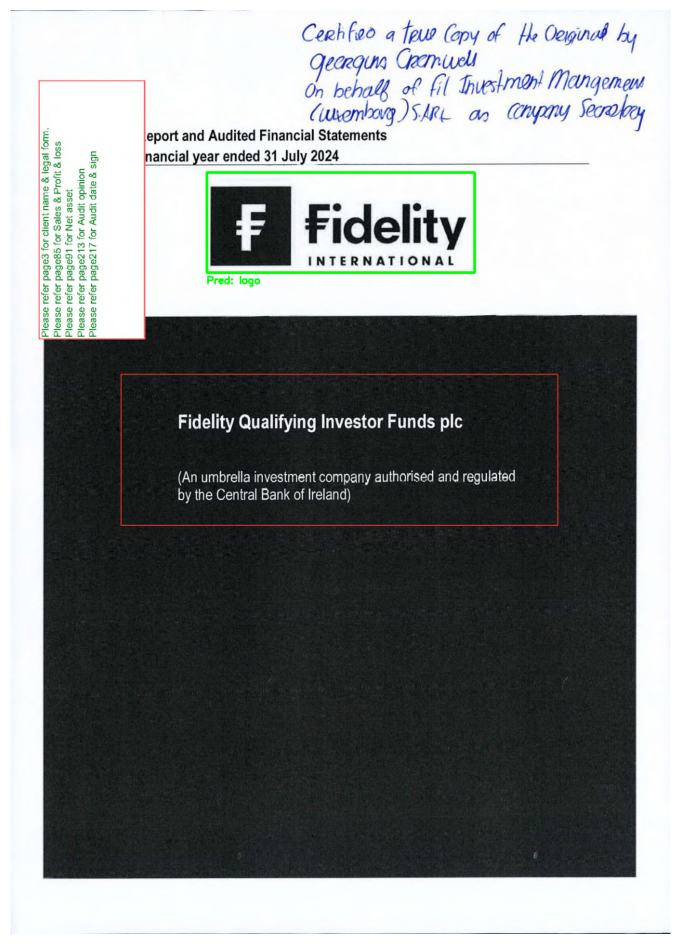

In [5]:

model.plot_bounding_boxes(TEST_IMAGE_PATH,output_structured)

## Test the Benchmark on a test image

In [3]:
import json
from tqdm import tqdm

test_json_path = "data_final/test.jsonl"

# Use a list comprehension to load each line as a JSON object
with open(test_json_path, 'r', encoding='utf-8') as f:
    test_json = [json.loads(line) for line in f]

test_dataset=[]
for line in tqdm(test_json):
    test_dataset.append({
        "image_path": line['messages'][0]['content'][0]['image'],
        "groundTruth": line['messages'][1]['content'][0]['text']
    })

100%|██████████| 536/536 [00:00<00:00, 594276.22it/s]


In [4]:
from utils.signature_benchmark import SignatureBenchmark
import json
benchmark=SignatureBenchmark(model)


Evaluating ALL Labels (Multi-Class):   3%|▎         | 14/536 [00:13<06:58,  1.25it/s]

⚠️ Warning: No bounding boxes found matching the regex.
Error processing /users/eleves-a/2025/youssef.sidhom/Object_detection_in_documents/data_final/images/test_aah97e00-page02_1_jpg.rf.4402f6102b0816dca70a492f5ee87040.jpg: name 'raw_output' is not defined


Evaluating ALL Labels (Multi-Class):   5%|▌         | 28/536 [00:29<10:25,  1.23s/it]

⚠️ Warning: No bounding boxes found matching the regex.
Error processing /users/eleves-a/2025/youssef.sidhom/Object_detection_in_documents/data_final/images/test_hcu72e00_1_jpg.rf.ca2dcdca0a6dcf19a18f8d94bac3e272.jpg: name 'raw_output' is not defined


Evaluating ALL Labels (Multi-Class):   7%|▋         | 36/536 [00:46<12:22,  1.48s/it]

...

⚠️ Warning: No bounding boxes found matching the regex.
Error processing /users/eleves-a/2025/youssef.sidhom/Object_detection_in_documents/data_final/images/test_vfs60f00_jpg.rf.784bc2ccf902f7a4952a75a812078127.jpg: name 'raw_output' is not defined


Evaluating ALL Labels (Multi-Class):  99%|█████████▊| 528/536 [10:36<00:14,  1.75s/it]

⚠️ Warning: No bounding boxes found matching the regex.
Error processing /users/eleves-a/2025/youssef.sidhom/Object_detection_in_documents/data_final/images/test_jgs60f00-page03_1_jpg.rf.29df76a37e2133417da9b9010e9f87a3.jpg: name 'raw_output' is not defined


Evaluating ALL Labels (Multi-Class): 100%|██████████| 536/536 [10:43<00:00,  1.20s/it]


📸 Saved Confusion Matrix plot to confusion_matrix_multi.png


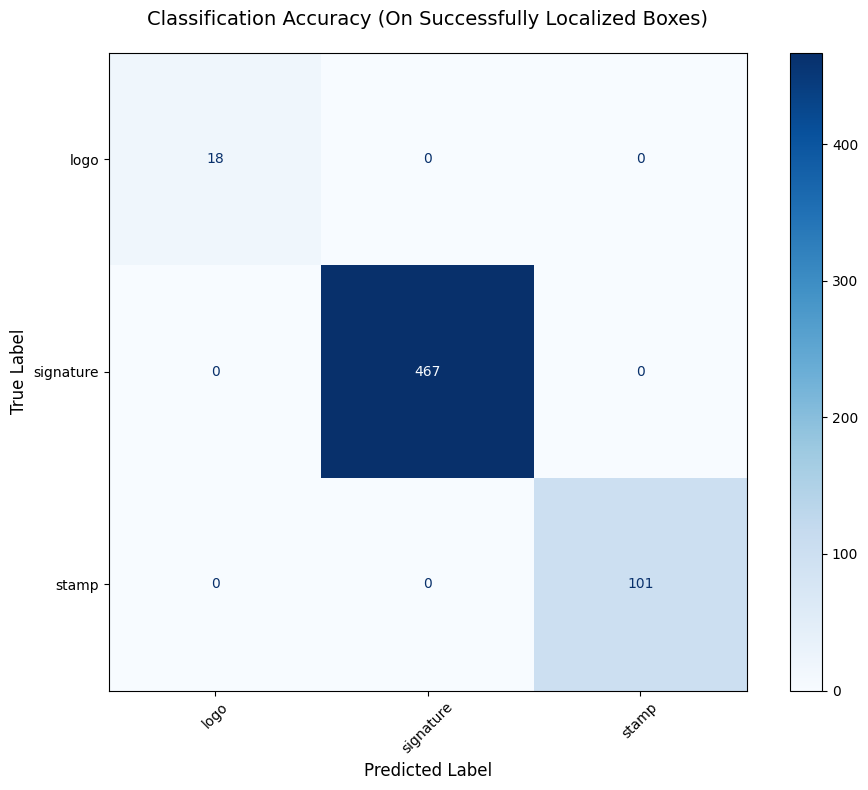


 📊 QWEN EVALUATION REPORT (536 Images)
 Threshold IoU: 0.7
 1. LOCALIZATION METRICS (Finding the box)
 Precision: 0.7503 | Recall: 0.7343
 F1-Score:  0.7422
---------------------------------------------------------------------------
 Successfully Localized (TP):         586
 Wrongly Predicted Boxes (FP):        195  <-- Failed to hit 0.7 IoU
 Missed Ground Truth Boxes (FN):      212
 Correctly Empty Images (TN):         33 / 38 (86.84%)
 Mean IoU of Successes:               0.8383
 Median IoU of Successes:             0.8434
---------------------------------------------------------------------------
 2. CLASSIFICATION METRICS (Labeling the correctly found boxes)
 Accuracy:  100.00%
---------------------------------------------------------------------------
 3. DETAILED PER-CLASS METRICS
---------------------------------------------------------------------------
 Label           | Precision | Recall    | F1-Score  | TP   | FP   | FN  
---------------------------------------------------

{'localization_f1_at_70': 0.7422,
 'precision': 0.7503,
 'recall': 0.7343,
 'mean_iou': 0.8382892491467577,
 'median_iou': 0.8434,
 'total_tp': 586,
 'total_fp': 195,
 'total_fn': 212,
 'true_negatives': 33,
 'total_negatives': 38,
 'classification_accuracy': 1.0,
 'per_class_metrics': {'logo': {'precision': 0.439,
   'recall': 0.5143,
   'f1': 0.4737,
   'tp': 18,
   'fp': 23,
   'fn': 17},
  'signature': {'precision': 0.7354,
   'recall': 0.7119,
   'f1': 0.7235,
   'tp': 467,
   'fp': 168,
   'fn': 189},
  'stamp': {'precision': 0.9619,
   'recall': 0.9439,
   'f1': 0.9528,
   'tp': 101,
   'fp': 4,
   'fn': 6}}}

In [5]:
benchmark.evaluate_multi_label(test_dataset)